In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import random
import kagglehub

In [ ]:
#path to Animals10 dataset
path = kagglehub.dataset_download("alessiocorrado99/animals10")
data_path = os.path.join(path, "raw-img") #path directly to images

# Italian to English translation of animals names
translate = {
    "cane": "dog", "gatto": "cat", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "ragno": "spider",
    "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel"
}

#transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)), #all images to have same size for processing
    transforms.ToTensor() #pytorch works with tensor, not raw images
])

dataset = datasets.ImageFolder(root=data_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

class_names_it = dataset.classes
class_names_en = [translate[name] for name in class_names_it]

print("📌 Classes (IT):", class_names_it)
print("📌 Classes (EN):", class_names_en)

Using Colab cache for faster access to the 'animals10' dataset.
📌 Classes (IT): ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
📌 Classes (EN): ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


In [ ]:
#count images in each class
print("Images per class:")
for cls_it in dataset.classes:
    cls_en = translate.get(cls_it)
    count = len(os.listdir(os.path.join(data_path, cls_it)))
    print(f"{cls_en}: {count} images")

Images per class:
dog: 4863 images
horse: 2623 images
elephant: 1446 images
butterfly: 2112 images
chicken: 3098 images
cat: 1668 images
cow: 1866 images
sheep: 1820 images
spider: 4821 images
squirrel: 1862 images


In [ ]:
#show samples from each class
def show_samples(data_path, classes_it, classes_en, samples=2):
    for cls_it, cls_en in zip(classes_it, classes_en):
        imgs = os.listdir(os.path.join(data_path, cls_it))
        for img_name in random.sample(imgs, samples):
            img_path = os.path.join(data_path, cls_it, img_name)
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(cls_en)  # Use English names of animals
            plt.axis('off')
            plt.show()

show_samples(data_path, class_names_it, class_names_en)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
widths, heights = [], []

for cls in dataset.classes:
    cls_path = os.path.join(data_path, cls)
    for img_name in os.listdir(cls_path):
        img = Image.open(os.path.join(cls_path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Width range:", min(widths), "-", max(widths))
print("Height range:", min(heights), "-", max(heights))

Width range: 60 - 6720
Height range: 57 - 6000


/tmp/ipython-input-3883277292.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([widths, heights], labels=['Widths', 'Heights'], vert=False)


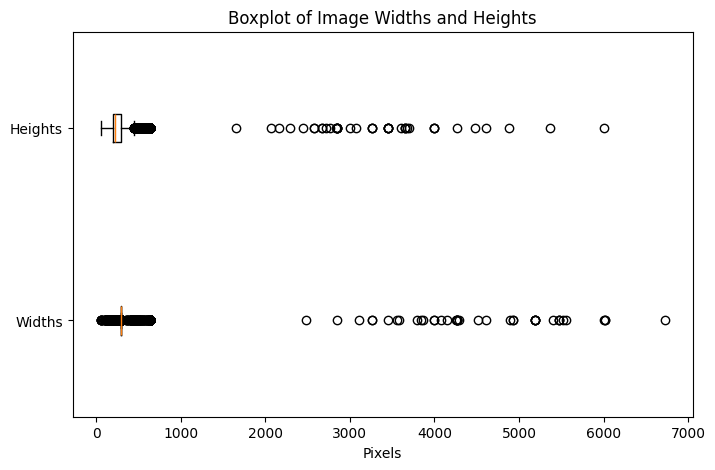

In [ ]:
#visualize size distribution
plt.figure(figsize=(8, 5))
plt.boxplot([widths, heights], labels=['Widths', 'Heights'], vert=False)
plt.title('Boxplot of Image Widths and Heights')
plt.xlabel('Pixels')
plt.show()

In [ ]:
#check for corrupted images
corrupted = []

for cls in dataset.classes:
    cls_path = os.path.join(data_path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)

print(f"Corrupted images: {len(corrupted)}")

Corrupted images: 0
